# Hyperparameter Sensitivity Analysis for Cluster Quilting

Systematically vary **number of patches** and **column overlap** to study their
effect on clustering performance (ARI against ground truth valence labels).

Based on Zheng, Chang & Allen (2024) — the paper notes diminishing efficacy
as the number of patches increases.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from scipy.sparse.linalg import svds
from pathlib import Path
from itertools import product
import warnings
warnings.filterwarnings('ignore')

## 1. Load & Preprocess Data

In [2]:
df = pd.read_csv('~/Downloads/trialdf_24sessions.csv', index_col=0)
meta_cols = ['valence', 'airstart', 'sucstart', 'ms_id', 'condition', 'inj_site', 'ms_n']
feature_cols = [c for c in df.columns if c not in meta_cols]
df = df.loc[~df['valence'].str.contains('CS')]

# Drop columns with >5% NaN, then drop remaining NaN rows
thresh = 0.05 * len(df)
feature_cols = [c for c in feature_cols if df[c].isna().sum() <= thresh]
df = df[feature_cols + meta_cols].dropna()

valence = df['valence'].values
X = StandardScaler().fit_transform(df[feature_cols].values)
M, N = X.shape

print(f'Data: {M} samples x {N} features')
print(f'Valence categories: {np.unique(valence)}')

Data: 129603 samples x 121 features
Valence categories: ['Air_US' 'ITI' 'Sucrose_US']


## 2. Full-Data Baseline

In [3]:
from sklearn.decomposition import PCA

X_pca = PCA(n_components=10).fit_transform(X)
baseline_labels = KMeans(n_clusters=3, n_init=20, random_state=42).fit_predict(X_pca)
baseline_ari = adjusted_rand_score(valence, baseline_labels)
print(f'Full-data K-Means baseline ARI: {baseline_ari:.4f}')

Full-data K-Means baseline ARI: 0.1853


## 3. Algorithm Functions

In [4]:
def generate_patches(shape, n_patches, min_size, max_size, min_overlap, rng=None):
    """Generate rectangular patches with guaranteed full row/column coverage."""
    if rng is None:
        rng = np.random.default_rng(42)

    M, N = shape
    min_rows, min_cols = min_size
    max_rows, max_cols = max_size

    # --- Row partition: random sizes scaled to sum to M ---
    raw_sizes = rng.integers(min_rows, max_rows + 1, size=n_patches).astype(float)
    row_sizes = np.round(raw_sizes / raw_sizes.sum() * M).astype(int)
    row_sizes[-1] = M - row_sizes[:-1].sum()
    breakpoints = np.concatenate([[0], np.cumsum(row_sizes)])

    # --- Column ranges: sliding window with guaranteed min_overlap ---
    col_starts = []
    col_ends = []
    col_stride = N / n_patches
    col_pos = 0.0
    for i in range(n_patches):
        width = rng.integers(min_cols, max_cols + 1)
        start = max(0, int(col_pos) - rng.integers(min_cols // 2, min_cols))
        end = min(N, start + width)

        if i > 0:
            max_start = col_ends[-1] - min_overlap
            if start > max_start:
                start = max(0, max_start)
                end = min(N, start + width)

        if i == n_patches - 1:
            end = N
            start = min(start, N - min_cols)
            if i > 0:
                start = min(start, col_ends[-1] - min_overlap)

        col_starts.append(start)
        col_ends.append(end)
        col_pos += col_stride

    patches = []
    for i in range(n_patches):
        row_idx = np.arange(breakpoints[i], breakpoints[i + 1])
        col_idx = np.arange(col_starts[i], col_ends[i])
        patches.append({'row_idx': row_idx, 'col_idx': col_idx})

    return patches


def greedy_patch_ordering(patches):
    """Algorithm 2: Forward search for patch ordering using column overlap."""
    M = len(patches)
    col_sets = [set(p['col_idx'].tolist()) for p in patches]

    best_score = -1
    best_pair = (0, 1)
    for i in range(M):
        for j in range(M):
            if i == j:
                continue
            score = len(col_sets[i] & col_sets[j])
            if score > best_score:
                best_score = score
                best_pair = (i, j)

    ordering = [best_pair[0], best_pair[1]]
    used = set(ordering)
    accumulated_cols = col_sets[best_pair[0]] | col_sets[best_pair[1]]

    for _ in range(2, M):
        best_next = -1
        best_s = -1
        for j in range(M):
            if j in used:
                continue
            s = len(col_sets[j] & accumulated_cols)
            if s > best_s:
                best_s = s
                best_next = j
        ordering.append(best_next)
        used.add(best_next)
        accumulated_cols |= col_sets[best_next]

    return ordering


def cluster_quilting(patches, ordering, r, K):
    """Algorithm 1 (column-overlap variant): Cluster Quilting.
    
    Uses truncated SVD (scipy.sparse.linalg.svds) for speed.
    """
    n_total = max(p['row_idx'][-1] for p in patches) + 1
    p_total = max(p['col_idx'][-1] for p in patches) + 1

    V_tilde = np.zeros((p_total, r))
    H_tilde = np.zeros((n_total, r))
    covered_cols = set()

    def truncated_svd(X_m, r):
        """Compute top-r SVD using scipy.sparse.linalg.svds."""
        k = min(r, min(X_m.shape) - 1)
        U, S, Vt = svds(X_m, k=k)
        # svds returns in ascending order; flip to descending
        idx = np.argsort(-S)
        return U[:, idx], S[idx], Vt[idx, :]

    # First patch
    m0 = ordering[0]
    X_m = patches[m0]['data']
    U, S, Vt = truncated_svd(X_m, r)
    U_r, S_r, V_r = U[:, :r], S[:r], Vt[:r, :].T
    row_idx = patches[m0]['row_idx']
    col_idx = patches[m0]['col_idx']
    V_tilde[col_idx, :] = V_r
    H_tilde[row_idx, :] = U_r * S_r[np.newaxis, :]
    covered_cols.update(col_idx.tolist())

    # Subsequent patches
    for step in range(1, len(ordering)):
        m = ordering[step]
        X_m = patches[m]['data']
        row_idx = patches[m]['row_idx']
        col_idx = patches[m]['col_idx']

        U, S, Vt = truncated_svd(X_m, r)
        U_r, S_r, V_r = U[:, :r], S[:r], Vt[:r, :].T

        current_cols = set(col_idx.tolist())
        overlap_global = sorted(current_cols & covered_cols)

        if len(overlap_global) < r:
            V_tilde[col_idx, :] = V_r
            H_tilde[row_idx, :] = U_r * S_r[np.newaxis, :]
            covered_cols.update(col_idx.tolist())
            continue

        col_idx_list = col_idx.tolist()
        global_to_local = {g: l for l, g in enumerate(col_idx_list)}
        local_overlap = [global_to_local[g] for g in overlap_global]

        V_m_overlap = V_r[local_overlap, :]
        V_tilde_overlap = V_tilde[overlap_global, :]

        G_m, _, _, _ = np.linalg.lstsq(V_m_overlap, V_tilde_overlap, rcond=None)

        new_global = sorted(current_cols - covered_cols)
        if new_global:
            new_local = [global_to_local[g] for g in new_global]
            V_tilde[new_global, :] = V_r[new_local, :] @ G_m

        H_m = U_r * S_r[np.newaxis, :]
        G_m_inv_T = np.linalg.solve(G_m.T, np.eye(r))
        H_tilde[row_idx, :] = H_m @ G_m_inv_T
        covered_cols.update(col_idx.tolist())

    # Post-processing
    Q_H, R_H = np.linalg.qr(H_tilde)
    Q_V, R_V = np.linalg.qr(V_tilde)
    U_small, S_final, Vt_small = np.linalg.svd(R_H @ R_V.T, full_matrices=False)
    U_hat = Q_H @ U_small
    features_for_kmeans = U_hat @ np.diag(S_final)

    km = KMeans(n_clusters=K, n_init=10, random_state=42)
    labels = km.fit_predict(features_for_kmeans)

    return labels

## 4. Sweep Runner

In [5]:
def run_single(X, valence, n_patches, min_overlap, seed, K=3, r=2):
    """Generate patches, run cluster quilting, return ARI.
    
    Dynamically adjusts min/max column widths so that min_overlap < min_cols
    and the patches can tile the feature space.
    Returns None if the configuration is infeasible.
    """
    M, N = X.shape

    # Ensure min_cols > min_overlap (required by generate_patches)
    min_cols = max(40, min_overlap + 5)
    max_cols = max(100, min_cols + 20)
    min_rows, max_rows = 40, 100

    # Feasibility: need enough room for n_patches with given overlap.
    # Each new patch advances by at least (min_cols - min_overlap) columns.
    advance = max(1, min_cols - min_overlap)
    min_span = min_cols + (n_patches - 1) * advance
    if min_span > N:
        return None

    rng = np.random.default_rng(seed)
    try:
        patch_specs = generate_patches(
            shape=(M, N), n_patches=n_patches,
            min_size=(min_rows, min_cols), max_size=(max_rows, max_cols),
            min_overlap=min_overlap, rng=rng
        )
    except Exception:
        return None

    # Build patch dicts with data
    patches = []
    for p in patch_specs:
        row_idx = p['row_idx']
        col_idx = p['col_idx']
        patches.append({
            'data': X[np.ix_(row_idx, col_idx)],
            'row_idx': row_idx,
            'col_idx': col_idx,
        })

    ordering = greedy_patch_ordering(patches)

    try:
        labels = cluster_quilting(patches, ordering, r=r, K=K)
    except Exception:
        return None

    return adjusted_rand_score(valence, labels)

## 5. Grid Sweep: n_patches x min_overlap

In [6]:
n_patches_list = [2, 3, 4, 5, 6, 8, 10]
overlap_list = [10, 20, 30, 40, 50, 60]
n_seeds = 3
seeds = list(range(n_seeds))

# Results storage: dict of (n_patches, overlap) -> list of ARI values
results = {}

total = len(n_patches_list) * len(overlap_list)
done = 0

print(f'{"n_patches":>10} {"overlap":>8} {"ARI_mean":>10} {"ARI_std":>10} {"n_valid":>8}')
print('-' * 50)

for np_, ov in product(n_patches_list, overlap_list):
    aris = []
    for s in seeds:
        a = run_single(X, valence, n_patches=np_, min_overlap=ov, seed=s)
        if a is not None:
            aris.append(a)

    done += 1
    if aris:
        results[(np_, ov)] = aris
        print(f'{np_:>10} {ov:>8} {np.mean(aris):>10.4f} {np.std(aris):>10.4f} {len(aris):>8}')
    else:
        print(f'{np_:>10} {ov:>8} {"skip":>10} {"":>10} {0:>8}')

print(f'\nCompleted {done}/{total} configurations')

 n_patches  overlap   ARI_mean    ARI_std  n_valid
--------------------------------------------------
         2       10     0.1734     0.0043        3
         2       20     0.1734     0.0043        3
         2       30     0.1729     0.0048        3
         2       40     0.1738     0.0021        3
         2       50     0.1774     0.0049        3
         2       60     0.1804     0.0032        3
         3       10     0.1659     0.0058        3
         3       20     0.1660     0.0047        3
         3       30     0.1674     0.0062        3
         3       40     0.1701     0.0054        3
         3       50     0.1732     0.0036        3
         3       60     0.1742     0.0036        3
         4       10       skip                   0
         4       20     0.1485     0.0192        3
         4       30     0.1498     0.0180        3
         4       40     0.1506     0.0187        3
         4       50     0.1685     0.0025        3
         4       60     0.1724 

## 6. Plots

In [7]:
Path('plots').mkdir(exist_ok=True)

# Build arrays for plotting
mean_ari = np.full((len(n_patches_list), len(overlap_list)), np.nan)
std_ari = np.full((len(n_patches_list), len(overlap_list)), np.nan)

for i, np_ in enumerate(n_patches_list):
    for j, ov in enumerate(overlap_list):
        if (np_, ov) in results:
            mean_ari[i, j] = np.mean(results[(np_, ov)])
            std_ari[i, j] = np.std(results[(np_, ov)])

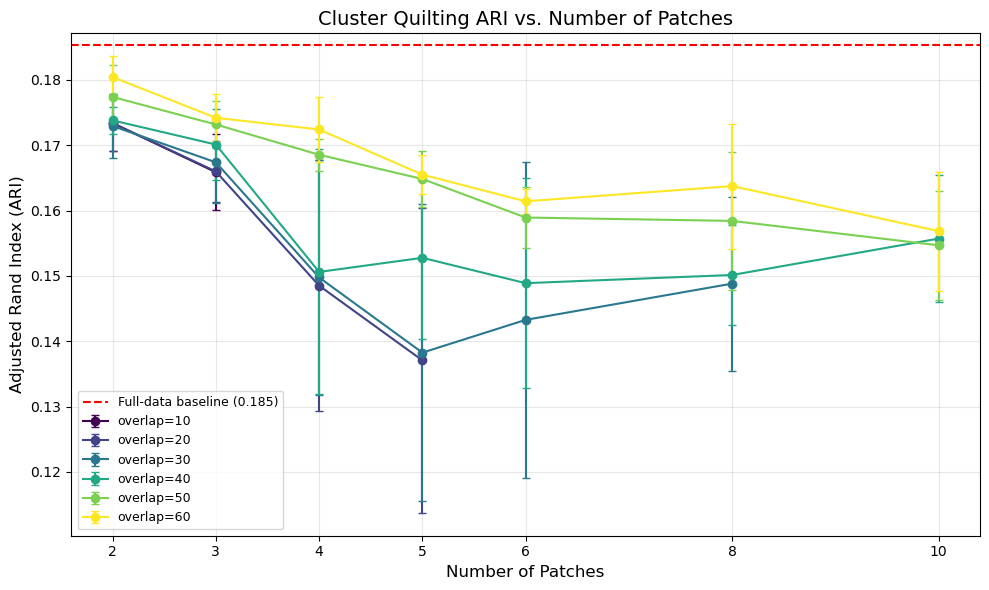

Saved plots/ari_vs_npatches.png


In [8]:
# --- Plot 1: ARI vs Number of Patches (one line per overlap) ---
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.cm.viridis
colors = [cmap(k / (len(overlap_list) - 1)) for k in range(len(overlap_list))]

for j, ov in enumerate(overlap_list):
    means = mean_ari[:, j]
    stds = std_ari[:, j]
    valid = ~np.isnan(means)
    if valid.sum() == 0:
        continue
    x = np.array(n_patches_list)[valid]
    y = means[valid]
    err = stds[valid]
    ax.errorbar(x, y, yerr=err, marker='o', capsize=3,
                label=f'overlap={ov}', color=colors[j])

ax.axhline(baseline_ari, color='red', linestyle='--', linewidth=1.5,
           label=f'Full-data baseline ({baseline_ari:.3f})')
ax.set_xlabel('Number of Patches', fontsize=12)
ax.set_ylabel('Adjusted Rand Index (ARI)', fontsize=12)
ax.set_title('Cluster Quilting ARI vs. Number of Patches', fontsize=14)
ax.legend(fontsize=9)
ax.set_xticks(n_patches_list)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/ari_vs_npatches.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved plots/ari_vs_npatches.png')

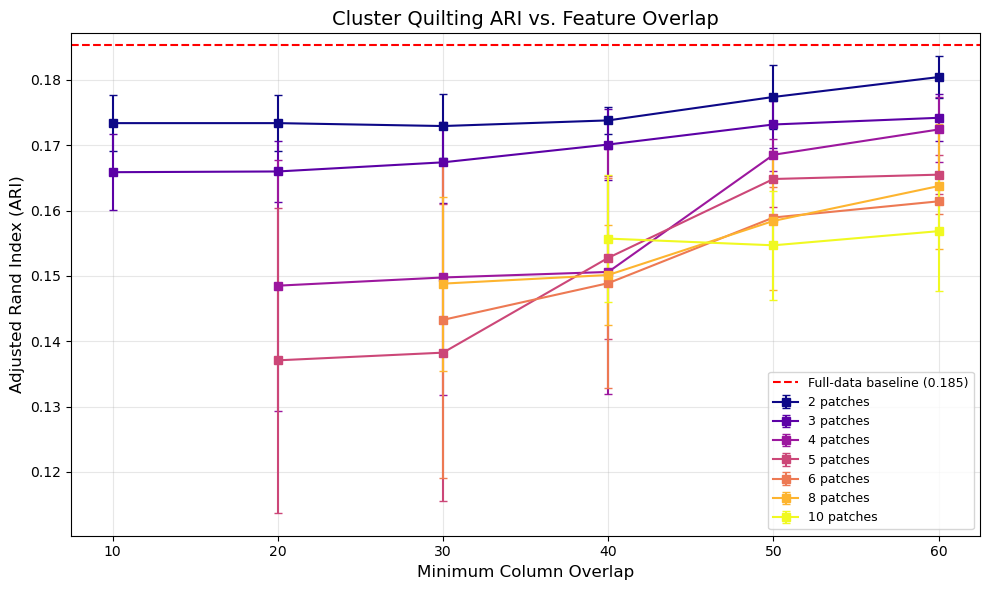

Saved plots/ari_vs_overlap.png


In [9]:
# --- Plot 2: ARI vs Overlap (one line per patch count) ---
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.cm.plasma
colors = [cmap(k / (len(n_patches_list) - 1)) for k in range(len(n_patches_list))]

for i, np_ in enumerate(n_patches_list):
    means = mean_ari[i, :]
    stds = std_ari[i, :]
    valid = ~np.isnan(means)
    if valid.sum() == 0:
        continue
    x = np.array(overlap_list)[valid]
    y = means[valid]
    err = stds[valid]
    ax.errorbar(x, y, yerr=err, marker='s', capsize=3,
                label=f'{np_} patches', color=colors[i])

ax.axhline(baseline_ari, color='red', linestyle='--', linewidth=1.5,
           label=f'Full-data baseline ({baseline_ari:.3f})')
ax.set_xlabel('Minimum Column Overlap', fontsize=12)
ax.set_ylabel('Adjusted Rand Index (ARI)', fontsize=12)
ax.set_title('Cluster Quilting ARI vs. Feature Overlap', fontsize=14)
ax.legend(fontsize=9)
ax.set_xticks(overlap_list)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/ari_vs_overlap.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved plots/ari_vs_overlap.png')

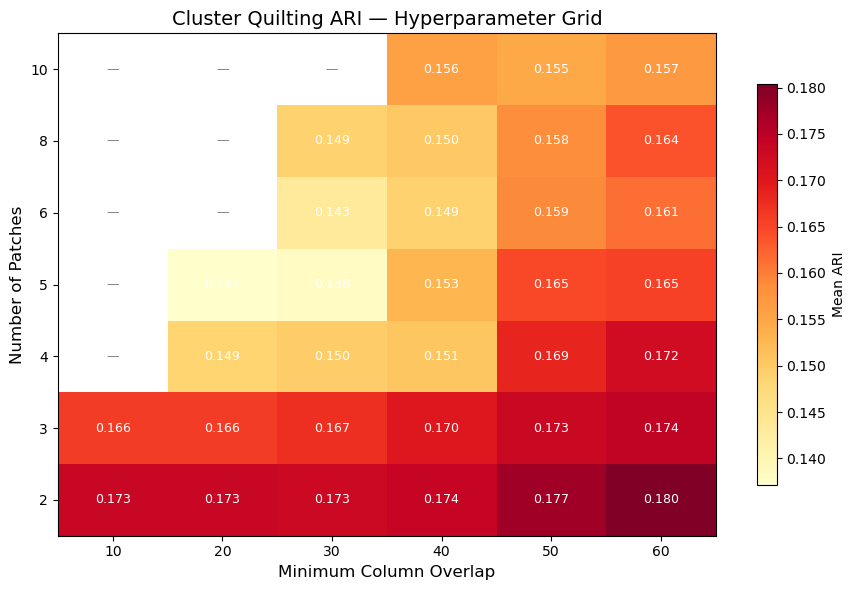

Saved plots/ari_heatmap.png


In [10]:
# --- Plot 3: Heatmap of ARI across (n_patches x overlap) grid ---
fig, ax = plt.subplots(figsize=(9, 6))

im = ax.imshow(mean_ari, aspect='auto', cmap='YlOrRd',
               origin='lower')

ax.set_xticks(range(len(overlap_list)))
ax.set_xticklabels(overlap_list)
ax.set_yticks(range(len(n_patches_list)))
ax.set_yticklabels(n_patches_list)
ax.set_xlabel('Minimum Column Overlap', fontsize=12)
ax.set_ylabel('Number of Patches', fontsize=12)
ax.set_title('Cluster Quilting ARI — Hyperparameter Grid', fontsize=14)

# Annotate cells with values
for i in range(len(n_patches_list)):
    for j in range(len(overlap_list)):
        val = mean_ari[i, j]
        if np.isnan(val):
            ax.text(j, i, '—', ha='center', va='center', fontsize=9, color='gray')
        else:
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=9,
                    color='white' if val > 0.12 else 'black')

plt.colorbar(im, ax=ax, label='Mean ARI', shrink=0.8)
plt.tight_layout()
plt.savefig('plots/ari_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved plots/ari_heatmap.png')